<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/Project_2_Jathiya_Hamidi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2  
## DATA 201 Spring 2026  
### Jathiya Hamidi  
### Predicting Food Insecurity Counts in Afghanistan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
from google.colab import files
uploaded = files.upload()

Saving ipc_afg_area_long_latest.csv to ipc_afg_area_long_latest (1).csv


In [8]:
df = pd.read_csv("ipc_afg_area_long_latest.csv")

df.head()

,Date of analysis,Country,Total country population,Level 1,Area,Validity period,From,To,Phase,Number,Percentage
0,Oct 2025,AFG,48595631,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,all,1679524,1.00
1,Oct 2025,AFG,48595631,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,3+,671809,0.40
2,Oct 2025,AFG,48595631,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,1,251929,0.15
3,Oct 2025,AFG,48595631,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,2,755786,0.45
4,Oct 2025,AFG,48595631,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,3,503857,0.30


In [9]:
df.shape

(987, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date of analysis          987 non-null    object 
 1   Country                   987 non-null    object 
 2   Total country population  987 non-null    int64  
 3   Level 1                   987 non-null    object 
 4   Area                      987 non-null    object 
 5   Validity period           987 non-null    object 
 6   From                      987 non-null    object 
 7   To                        987 non-null    object 
 8   Phase                     987 non-null    object 
 9   Number                    987 non-null    int64  
 10  Percentage                987 non-null    float64
dtypes: float64(1), int64(2), object(8)
memory usage: 84.9+ KB


In [11]:
df.isnull().sum()

,0
Date of analysis,0
Country,0
Total country population,0
Level 1,0
Area,0
Validity period,0
From,0
To,0
Phase,0
Number,0


## Introduction

The dataset used in this project comes from the Integrated Food Security Phase Classification (IPC), which provides humanitarian data on food insecurity levels in Afghanistan. This dataset focuses on multiple areas in Afghanistan and reports the estimated number and percentage of people experiencing different food insecurity.

The population of interest in this study is residents living in various areas of Afghanistan. Each observation represents one area and one IPC phase category, showing how many individuals fall into that level of food insecurity. The data was collected through humanitarian monitoring and food security assessments.

One limitation of the dataset is that it only reflects one country and one general analysis period. In addition, humanitarian datasets may contain estimation uncertainty because some regions can be difficult to assess due to conflict or accessibility.

Dataset Source: IPC Afghanistan Food Security Data.

## Data Overview

The original dataset contains 987 observations and 11 variables. Each row represents one Afghan area measured under a specific food insecurity phase. The dataset includes both quantitative and categorical variables, which makes it good for regression modeling.

There were no missing values in the dataset, and during preprocessing the variables with no variation like Date of analysis, Country, and Total country population were removed because they do not provide information helpful for this project. In addition, rows where the Phase variable was labeled as "all" were removed because these rows represent overall summary totals instead of individual food insecurity severity categories.

The target variable selected for this regression project is Number, which represents the estimated number of people affected in each area and phase category.

# Data Cleaning

In [12]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Date of analysis : 1
Country : 1
Total country population : 1
Level 1 : 8
Area : 47
Validity period : 3
From : 3
To : 3
Phase : 7
Number : 393
Percentage : 20


In [13]:
df = df.drop(columns=["Date of analysis", "Country", "Total country population"])

In [14]:
df = df[df["Phase"] != "all"]

In [15]:
df.shape

(846, 8)

In [16]:
df["Phase"].unique()

array(['3+', '1', '2', '3', '4', '5'], dtype=object)

In [17]:
df.head()

,Level 1,Area,Validity period,From,To,Phase,Number,Percentage
1,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,3+,671809,0.40
2,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,1,251929,0.15
3,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,2,755786,0.45
4,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,3,503857,0.30
5,North Eastern Region,Badakhshan,current,2025-09-01,2025-10-31,4,167952,0.10


### Variable Description Table

| Variable Name | Type | Description |
|---------------|------|-------------|
| Level 1 | Categorical | Broad geographic region of Afghanistan |
| Area | Categorical | The specific local area in the region |
| Validity period | Categorical | Time of the IPC food assessment |
| From | Categorical/Date | Beginning date of the period |
| To | Categorical/Date | Ending date of the period |
| Phase | Categorical | IPC food insecurity severity phase |
| Number | Quantitative | Estimated number of individuals |
| Percentage | Quantitative | Percentage of individuals in the area |

## 4. Data Analysis and Modeling


a. Data Exploration and Visualization

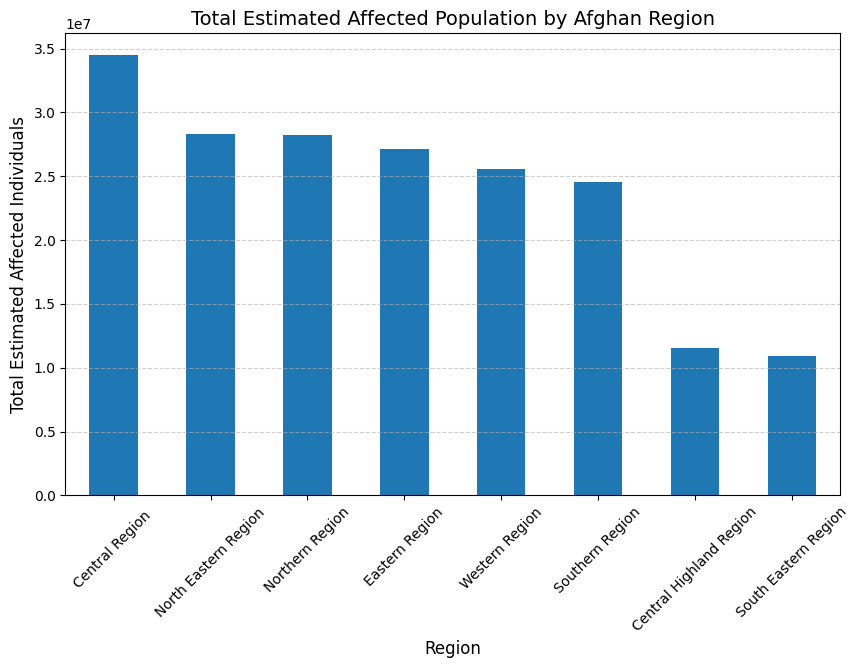

In [18]:
top_regions = df.groupby("Level 1")["Number"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top_regions.plot(kind='bar')
plt.title("Total Estimated Affected Population by Afghan Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Estimated Affected Individuals", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The bar chart shows that the total estimated number of food insecure individuals differs noticeably across Afghan regions. Some regions report  larger affected populations than others, indicating that food insecurity is not evenly distributed geographically. This regional variation shows that location may play an important role in predicting the number of affected individuals and should be included in the regression analysis.

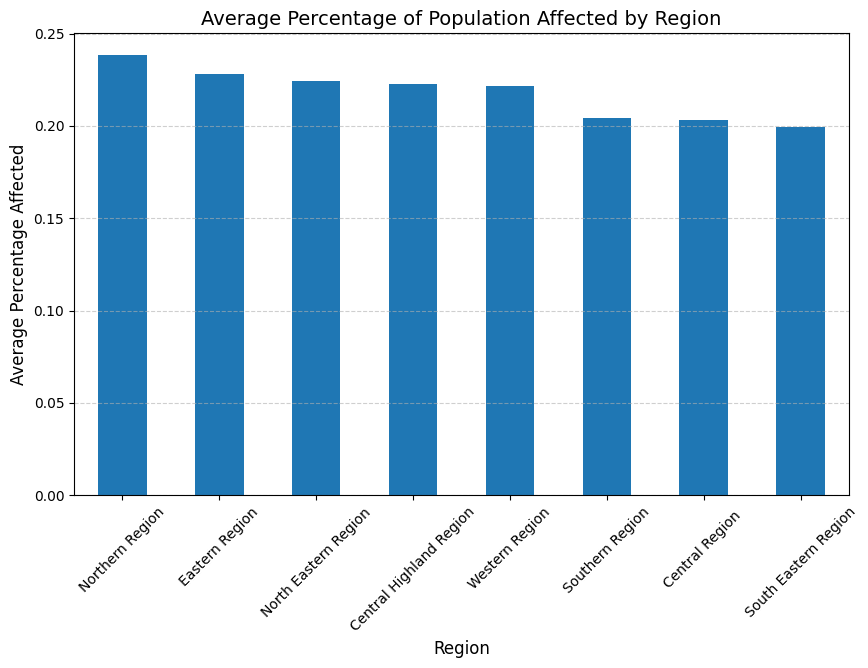

In [19]:
region_percent = df.groupby("Level 1")["Percentage"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
region_percent.plot(kind='bar')
plt.title("Average Percentage of Population Affected by Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Percentage Affected", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

This graph compares the average percentage of the population affected by food insecurity across Afghan regions. The results show that some regions experience a noticeably larger proportion of residents facing food insecurity than others. This indicates that the severity of food insecurity is geographically uneven.

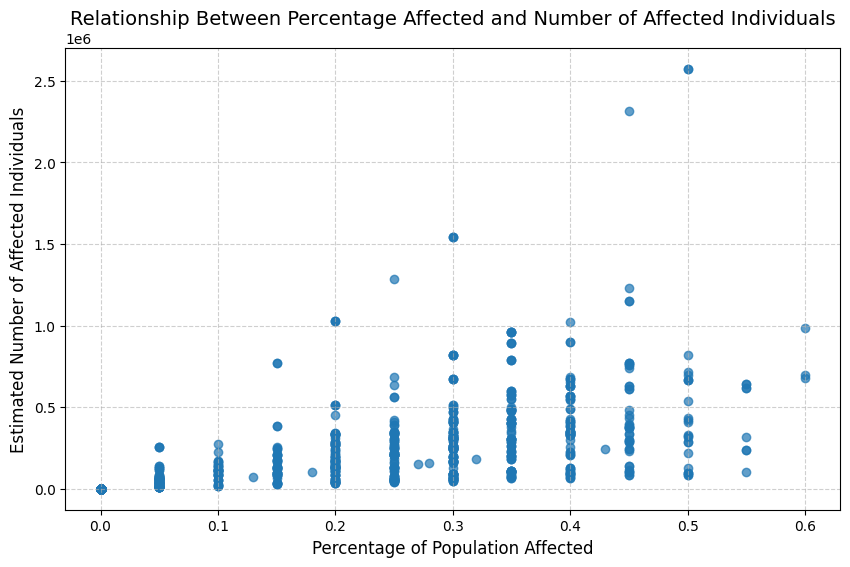

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df["Percentage"], df["Number"], alpha=0.7)
plt.title("Relationship Between Percentage Affected and Number of Affected Individuals", fontsize=14)
plt.xlabel("Percentage of Population Affected", fontsize=12)
plt.ylabel("Estimated Number of Affected Individuals", fontsize=12)
plt.grid(linestyle='--', alpha=0.6)
plt.show()

The scatterplot shows a positive relationship between Percentage and Number. As the percentage of the population affected increases, the estimated number of affected individuals also tends to rise. Although the data points are somewhat spread out, the upward trend suggests that Percentage is an important quantitative predictor for the regression model.

b. Train/Test Split


In [21]:
X = df[["Percentage", "Level 1"]]
y = df["Number"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (676, 8)
Testing set shape: (170, 8)


For the  modeling, this dataset was divided into a training set and a testing set using an 80/20 split, the training set was used to build the regression model, while the testing set was saved to evaluate how well the model performs on unseen observations.
For the basel tne model, Percentage and Level 1 region were selected as the initial predictors. Percentage was chosen because it directly reflects the share of the population affected, while Level 1 was to show for geographic differences across Afghanistan.

c. Build a Baseline Model


In [22]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("Baseline RMSE:", rmse_base)
print("Baseline R^2:", r2_base)

Baseline RMSE: 207279.88204620613
Baseline R^2: 0.3610910518692443


d. Improve Your Model


In [23]:
X2 = df[["Percentage", "Level 1", "Phase", "Area"]]
y2 = df["Number"]
X2 = pd.get_dummies(X2, drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

improved_model = LinearRegression()
improved_model.fit(X2_train, y2_train)
y_pred_improved = improved_model.predict(X2_test)

rmse_improved = np.sqrt(mean_squared_error(y2_test, y_pred_improved))
r2_improved = r2_score(y2_test, y_pred_improved)

print("Improved RMSE:", rmse_improved)
print("Improved R^2:", r2_improved)

Improved RMSE: 125002.40671504065
Improved R^2: 0.7676399750933143


Improved Regression Model

To improve the baseline model, two more variables were added, Phase and Area. This means the second model used Percentage, Level 1 region, Phase, and Area as predictors.
This change was made because the earlier graphs showed that food insecurity is different across regions, and the scatterplot showed that Percentage is related to Number. Since broad region alone may not explain all of the differences, adding Phase and the specific Area gives the model more detail about severity and location.

After running the new model the results were compared to the baseline model using RMSE and R^2. The new model had a lower RMSE and a higher R^2, which means it made better predictions. This shows that adding Phase and Area helped the model explain the data more accurately.

e. Compare Models


The baseline and improved regression models were compared using RMSE and R^2, the baseline model had an RMSE of about 207,280 and an R^2 of 0.361. After adding Phase and Area, the improved model had an RMSE of about 125,002 and an R^2 of 0.768.

The lower RMSE means that the improved model made predictions with less error, while the higher R^2 which means that it explained much more of the variation. Overall, the improved model performed much better than the baseline model, showing that the added predictors provided more important information that the first model was missing.

**f. Interpret Your Final Model**


In [26]:
coef_df = pd.DataFrame({
    "Variable": X2.columns,
    "Coefficient": improved_model.coef_})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(10)

,Variable,Coefficient,Abs_Coefficient
0,Percentage,1.034179e+06,1.034179e+06
33,Area_Kabul Urban,8.232119e+05,8.232119e+05
41,Area_Kunduz Urban,-3.345057e+05,3.345057e+05
15,Area_Baghlan Urban,-3.278872e+05,3.278872e+05
45,Area_Nangarhar,3.185959e+05,3.185959e+05
56,Area_Takhar Urban,-3.128774e+05,3.128774e+05
26,Area_Hilmand,2.802662e+05,2.802662e+05
51,Area_Panjsher,-2.545145e+05,2.545145e+05
28,Area_Hirat,2.287266e+05,2.287266e+05
48,Area_Nuristan,-2.096213e+05,2.096213e+05



The final regression model shows that Percentage is the most important predictor in estimating the Number of affected individuals. Its coefficient is the largest in the model, this means that the percentage of the population affected increases, the predicted number of food insecure people also increases.

The model also shows that geographic location plays an important role as well, many specific Area variables had bigger coefficients. This means that food insecurity is not only influenced by the percentage affected, but also by where the population is located for example, Kabul is the capital therefore the popluation of indivuials who are food insecure would be much higher.

In linear regression, coefficients show the amount of change in the response variable when a predictor changes while the other variables are held constant, positive coefficients also increase the predicted Number, while negative coefficients decrease it. Overall, the final model suggests that both percentage and local geographic area strongly affect the estimated number of food insecure individuals.

**g. Predictions**


In [25]:
new_data = pd.DataFrame({
    "Percentage": [0.20, 0.35, 0.50],
    "Level 1": ["North Eastern Region", "Central Region", "Southern Region"],
    "Phase": ["2", "3", "4"],
    "Area": ["Badakhshan", "Kabul Urban", "Hilmand"]
})

new_data_encoded = pd.get_dummies(new_data)
new_data_encoded = new_data_encoded.reindex(columns=X2.columns, fill_value=0)

predictions = improved_model.predict(new_data_encoded)

print(predictions)

[ 381416.58182016 1175872.06418236  780651.91537948]




Using the final regression model, predictions were made for three new hypothetical observations with different percentages, phases, and regional locations. The predicted numbers of affected individuals were approximately 381,417, 1,175,872, and 780,652.

These results show that the model can estimate food insecurity counts under different humanitarian conditions. In general, observations with higher affected percentages, more severe food insecurity phases, and certain geographic locations produced larger predicted numbers of affected individuals.

**5. Conclusions and Recommendations**

This project used Afghanistan IPC food insecurity data to predict the estimated number of affected individuals across different regions, the exploratory analysis showed that food insecurity varies by geographic location and that higher affected percentages are associated with higher population counts. These patterns showed that regional and severity related variables would be useful predictors in the regression model.

The baseline model showed only moderate performance, with an R^2 of 0.361. After adding Phase and Area, the improved model performed better, it lessened RMSE and increasing R^2 to 0.768. This means the final model explained a large portion of the variation in the response variable and showed better than the baseline model on the testing data.

One challenge in this project is that humanitarian data is based on estimates and may not perfectly reflect exact real world counts also, in addition, this dataset only covers Afghanistan during one assessment period. In the future, the model could be improved by adding more variables like poverty, conflict intensity, or population density to capture additional causes of food insecurity.